In [ ]:
#Simulación: impacto de omitir cada ingrediente en un pastel
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
# ---------------------- Ingredientes y receta base ----------------------
ingredientes = [
    "Harina", "Azucar", "Mantequilla", "Huevos", "Leche",
    "Agua", "Aceite", "PolvoHornear", "Sal", "Vainilla",
    "Cacao", "Yogur", "Miel", "Bicarbonato", "Maicena",
    "Crema", "Limon", "Canela", "Nueces", "ChocolateChips"
]

receta_base = np.array([
    300,180,120,150,150,50,30,10,3,5,0,80,30,2,20,50,10,2,40,60
], dtype=float)


In [ ]:
# ---------------------- Modelo ----------------------
w_lineal = np.array([
    0.08,0.05,0.06,0.07,0.04,
    0.01,0.03,0.09,0.02,0.03,
    0.04,0.03,0.02,0.03,0.02,
    0.02,0.02,0.02,0.02,0.02
])
w_lineal = w_lineal / w_lineal.sum()

OBJ = {
    "humedad":   (receta_base[[4,5,11,12,15]].sum() + 0.5*receta_base[6], 0.10),
    "estructura":(receta_base[[0,3,14]].sum(),                               0.12),
    "dulzor":    (receta_base[[1,12,19]].sum(),                               0.15),
    "grasa":     (receta_base[[2,6,15]].sum(),                                0.12),
}

def score_pastel(vec: np.ndarray) -> float:
    v = vec.copy()
    contrib_lineal = (w_lineal * np.log1p(np.maximum(v, 0))).sum()
    harina, azucar, mantequilla, huevos = v[0],v[1],v[2],v[3]
    leche, agua, aceite = v[4],v[5],v[6]
    polvo, sal, vainilla = v[7],v[8],v[9]
    cacao, yogur, miel = v[10],v[11],v[12]
    bicar, maicena, crema = v[13],v[14],v[15]
    limon, canela, nueces, chips = v[16],v[17],v[18],v[19]

    def sy(a,b): return math.sqrt(max(a,0)*max(b,0))
    inter = 0
    inter += 0.20*sy(harina, agua+leche)
    inter += 0.18*sy(azucar, mantequilla+aceite)
    inter += 0.15*sy(huevos, polvo+bicar)
    inter += 0.10*sy(cacao, azucar)
    inter += 0.08*sy(vainilla, azucar)
    inter += 0.06*sy(yogur+limon, bicar)
    inter += 0.05*sy(maicena, harina)
    inter += 0.05*sy(crema, mantequilla)

    humedad = (leche+agua+yogur+miel+crema)+0.5*aceite
    estructura = harina+0.6*huevos+0.3*maicena
    dulzor = azucar+0.6*miel+0.3*chips
    grasa = mantequilla+0.5*aceite+0.6*crema
    def penal(v,o,t): 
        d=abs(v-o)/(o+1e-9)
        exceso=max(d-t,0)
        return exceso**2
    pen=0
    pen+=2.5*penal(humedad,OBJ["humedad"][0],OBJ["humedad"][1])
    pen+=2.0*penal(estructura,OBJ["estructura"][0],OBJ["estructura"][1])
    pen+=1.8*penal(dulzor,OBJ["dulzor"][0],OBJ["dulzor"][1])
    pen+=1.8*penal(grasa,OBJ["grasa"][0],OBJ["grasa"][1])
    pen+=0.8*max(0.0,sal-4)**2/100.0

    bruto=25*contrib_lineal+0.02*inter-8.0*pen
    return float(max(0,min(100,100/(1+math.exp(-0.12*(bruto-10))))))


In [ ]:
# ---------------------- Experimento ----------------------
puntaje_base=score_pastel(receta_base)
resultados=[]
for i,ing in enumerate(ingredientes):
    rec=receta_base.copy()
    rec[i]=0
    p=score_pastel(rec)
    resultados.append((ing,round(p,3),round(p-puntaje_base,3)))

df=pd.DataFrame(resultados,columns=["Ingrediente","Puntaje_sin","Delta_vs_base"])
df=df.sort_values("Delta_vs_base")
print("Puntaje base:",round(puntaje_base,3))
print(df.to_string(index=False))

Puntaje base: 99.995
   Ingrediente  Puntaje_sin  Delta_vs_base
        Harina       99.902         -0.093
        Azucar       99.959         -0.036
   Mantequilla       99.961         -0.034
        Huevos       99.974         -0.021
         Leche       99.984         -0.011
  PolvoHornear       99.987         -0.008
         Yogur       99.990         -0.004
         Crema       99.992         -0.003
        Aceite       99.991         -0.003
       Maicena       99.993         -0.002
          Miel       99.993         -0.002
ChocolateChips       99.992         -0.002
        Nueces       99.993         -0.002
   Bicarbonato       99.994         -0.001
           Sal       99.994         -0.001
          Agua       99.994         -0.001
         Limon       99.993         -0.001
        Canela       99.994         -0.001
      Vainilla       99.993         -0.001
         Cacao       99.995          0.000


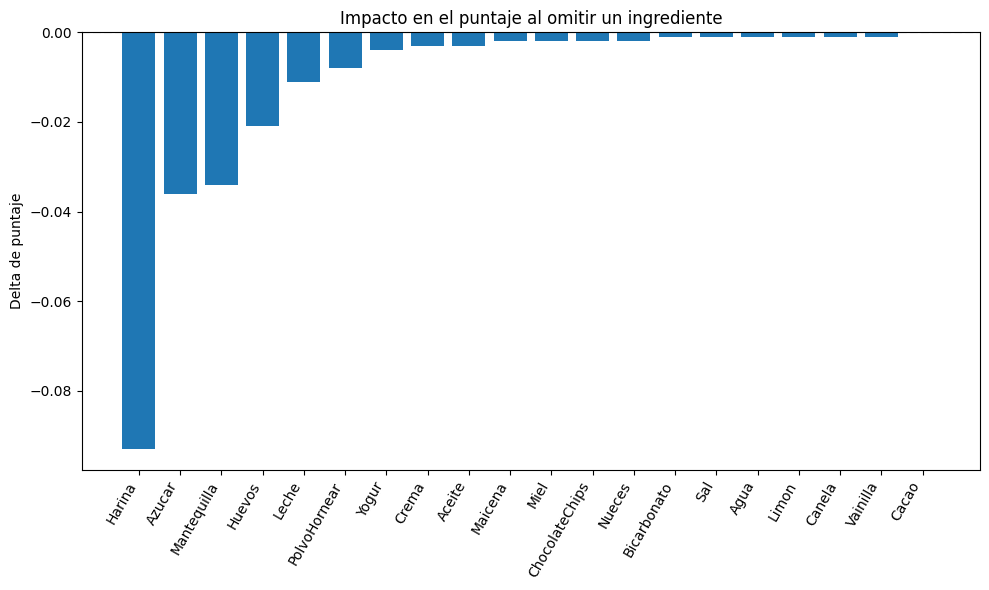

In [ ]:
# ---------------------- Gráfica ----------------------
plt.figure(figsize=(10,6))
plt.bar(df["Ingrediente"],df["Delta_vs_base"])
plt.axhline(0,linestyle="--",color="gray")
plt.title("Impacto en el puntaje al omitir un ingrediente")
plt.ylabel("Delta de puntaje")
plt.xticks(rotation=60,ha="right")
plt.tight_layout()
plt.show()
